In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
trxn= pd.read_csv('Retail_Data_Transactions.csv')
trxn

,customer_id,trans_date,tran_amount
0,CS5295,11-Feb-13,35
1,CS4768,15-Mar-15,39
2,CS2122,26-Feb-13,52
3,CS1217,16-Nov-11,99
4,CS1850,20-Nov-13,78
...,...,...,...
124995,CS8433,26-Jun-11,64
124996,CS7232,19-Aug-14,38
124997,CS8731,28-Nov-14,42
124998,CS8133,14-Dec-13,13


In [3]:
response=pd.read_csv('Retail_Data_Response.csv')
response

,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1
...,...,...
6879,CS8996,0
6880,CS8997,0
6881,CS8998,0
6882,CS8999,0


In [4]:
df= trxn.merge(response, on='customer_id', how='left')
df

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


In [5]:
#features
df.dtypes

customer_id     object
trans_date      object
tran_amount      int64
response       float64
dtype: object

In [6]:
df.shape

(125000, 4)

In [7]:
df.tail()

,customer_id,trans_date,tran_amount,response
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0
124999,CS7996,13-Dec-14,36,0.0


In [8]:
df.describe()

,tran_amount,response
count,125000.000000,124969.000000
mean,64.991912,0.110763
std,22.860006,0.313840
min,10.000000,0.000000
25%,47.000000,0.000000
50%,65.000000,0.000000
75%,83.000000,0.000000
max,105.000000,1.000000


In [9]:
df.isnull().sum()

customer_id     0
trans_date      0
tran_amount     0
response       31
dtype: int64

In [10]:
df.dropna()
df

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


In [11]:
#change dtype
set(df['response'])
df['trans_date']= pd.to_datetime(df['trans_date'])
df['response']=df['response'].fillna(0).astype('int64')
df

,customer_id,trans_date,tran_amount,response
0,CS5295,2013-02-11,35,1
1,CS4768,2015-03-15,39,1
2,CS2122,2013-02-26,52,0
3,CS1217,2011-11-16,99,0
4,CS1850,2013-11-20,78,0
...,...,...,...,...
124995,CS8433,2011-06-26,64,0
124996,CS7232,2014-08-19,38,0
124997,CS8731,2014-11-28,42,0
124998,CS8133,2013-12-14,13,0


In [12]:
set(df['response'])

{0, 1}

In [13]:
df.dtypes

customer_id            object
trans_date     datetime64[ns]
tran_amount             int64
response                int64
dtype: object

In [14]:
#z score
from scipy import stats
import numpy as np

#calc z score
z_scores=np.abs(stats.zscore(df['tran_amount']))
#set a threshold
threshold= 3
outliers=z_scores>threshold 

print(df['tran_amount'][outliers])


Series([], Name: tran_amount, dtype: int64)


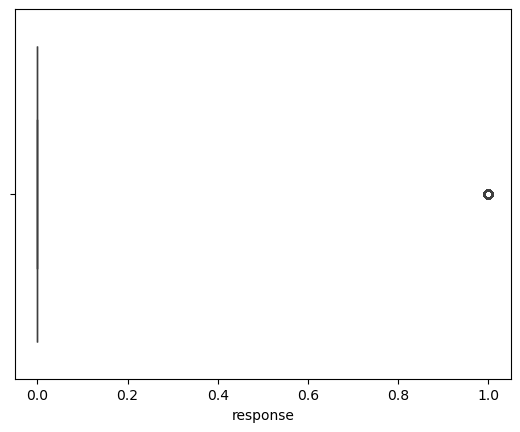

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['response'])
plt.show()

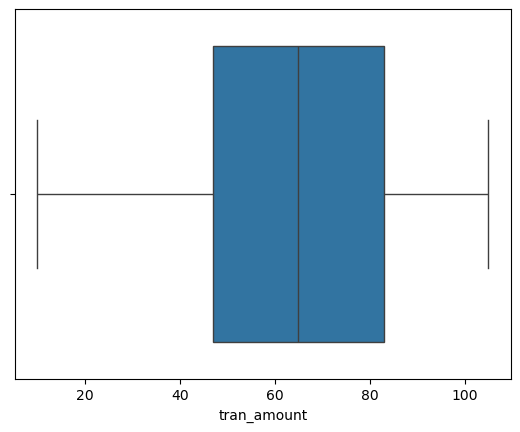

In [16]:
sns.boxplot(x=df['tran_amount'])
plt.show()

In [17]:
#creating new column
df['month']=df['trans_date'].dt.month
df

,customer_id,trans_date,tran_amount,response,month
0,CS5295,2013-02-11,35,1,2
1,CS4768,2015-03-15,39,1,3
2,CS2122,2013-02-26,52,0,2
3,CS1217,2011-11-16,99,0,11
4,CS1850,2013-11-20,78,0,11
...,...,...,...,...,...
124995,CS8433,2011-06-26,64,0,6
124996,CS7232,2014-08-19,38,0,8
124997,CS8731,2014-11-28,42,0,11
124998,CS8133,2013-12-14,13,0,12


In [18]:
#which 3 month have had the highest number of transactio amount???
Monthly_sales=df.groupby('month')['tran_amount'].sum()
Monthly_sales=Monthly_sales.sort_values(ascending=False).reset_index().head(3)
Monthly_sales


,month,tran_amount
0,8,726921
1,10,725320
2,1,724107


In [19]:
#Customers having highest numbers of order
customer_counts=df['customer_id'].value_counts().reset_index()
customer_counts

,customer_id,count
0,CS4424,39
1,CS4320,38
2,CS3799,36
3,CS3805,35
4,CS1215,35
...,...,...
6884,CS8504,4
6885,CS7716,4
6886,CS8376,4
6887,CS7224,4


In [20]:
top_5_cust=customer_counts.sort_values(by='count',ascending=False).head(5)
top_5_cust

,customer_id,count
0,CS4424,39
1,CS4320,38
2,CS3799,36
4,CS1215,35
3,CS3805,35


<Axes: xlabel='customer_id', ylabel='count'>

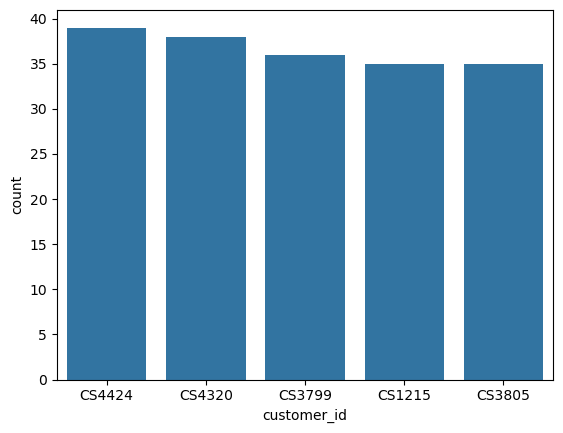

In [21]:
sns.barplot(x='customer_id',y='count',data=top_5_cust)

In [22]:
customer_sales=df.groupby('customer_id')['tran_amount'].sum().reset_index()
customer_sales
#sort
top_5_sale=customer_sales.sort_values(by='tran_amount',ascending=False).head(5)
top_5_sale

,customer_id,tran_amount
3312,CS4424,2933
3208,CS4320,2647
4640,CS5752,2612
3548,CS4660,2527
2687,CS3799,2513


<Axes: xlabel='customer_id', ylabel='tran_amount'>

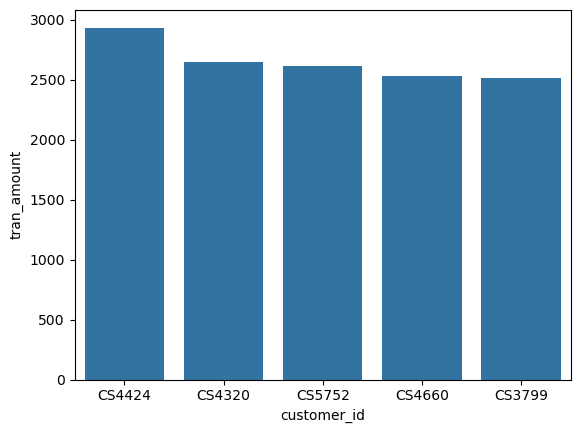

In [23]:
sns.barplot(x='customer_id',y='tran_amount',data=top_5_sale)


# Advance analysis #

## Time series ##

In [24]:
import matplotlib.dates as mdates
df['month_year']=df['trans_date'].dt.to_period('M')
df

,customer_id,trans_date,tran_amount,response,month,month_year
0,CS5295,2013-02-11,35,1,2,2013-02
1,CS4768,2015-03-15,39,1,3,2015-03
2,CS2122,2013-02-26,52,0,2,2013-02
3,CS1217,2011-11-16,99,0,11,2011-11
4,CS1850,2013-11-20,78,0,11,2013-11
...,...,...,...,...,...,...
124995,CS8433,2011-06-26,64,0,6,2011-06
124996,CS7232,2014-08-19,38,0,8,2014-08
124997,CS8731,2014-11-28,42,0,11,2014-11
124998,CS8133,2013-12-14,13,0,12,2013-12


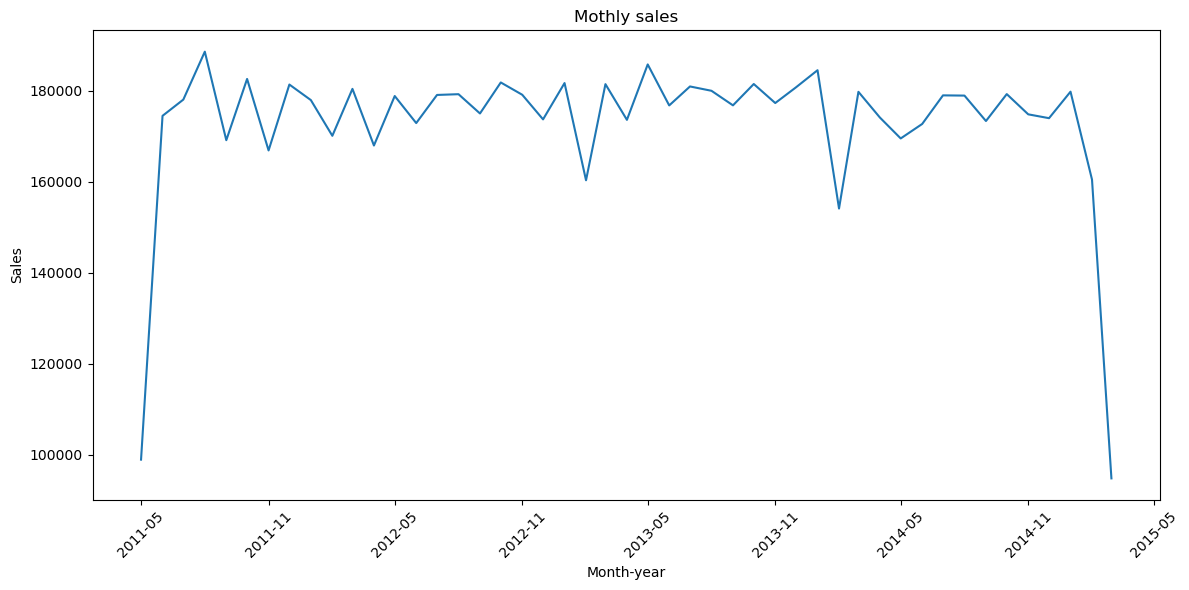

In [25]:
monthly_sales=df.groupby('month_year')['tran_amount'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index ,monthly_sales.values)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel('Month-year')
plt.ylabel('Sales')
plt.title('Mothly sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Cohort segmentation ##

In [26]:
#recency
recency=df.groupby('customer_id')['trans_date'].max()

#frequency
frequency=df.groupby('customer_id')['trans_date'].count()

#monetary
monetary=df.groupby('customer_id')['tran_amount'].sum()

#Combine
rfm=pd.DataFrame({'recency':recency ,'frequency':frequency, 'monetary':monetary})
rfm

,recency,frequency,monetary
customer_id,,,
CS1112,2015-01-14,15,1012
CS1113,2015-02-09,20,1490
CS1114,2015-02-12,19,1432
CS1115,2015-03-05,22,1659
CS1116,2014-08-25,13,857
...,...,...,...
CS8996,2014-12-09,13,582
CS8997,2014-06-28,14,543
CS8998,2014-12-22,13,624


In [27]:
#customer_segmentation
def segment_customer(row):
    if row['recency'].year>=2012 and row['frequency']>=15 and row['monetary']>=1000:
        return 'P0'
    elif (2011<=row['recency'].year) and (row['recency'].year<2012) and (10<row['frequency']<=15) and (500<row['monetary']<=1000):
        return 'P1'
    else:
        return 'P2'
rfm['segment']=rfm.apply(segment_customer, axis=1)
rfm

,recency,frequency,monetary,segment
customer_id,,,,
CS1112,2015-01-14,15,1012,P0
CS1113,2015-02-09,20,1490,P0
CS1114,2015-02-12,19,1432,P0
CS1115,2015-03-05,22,1659,P0
CS1116,2014-08-25,13,857,P2
...,...,...,...,...
CS8996,2014-12-09,13,582,P2
CS8997,2014-06-28,14,543,P2
CS8998,2014-12-22,13,624,P2


## Churn analysis ##

<Axes: xlabel='response'>

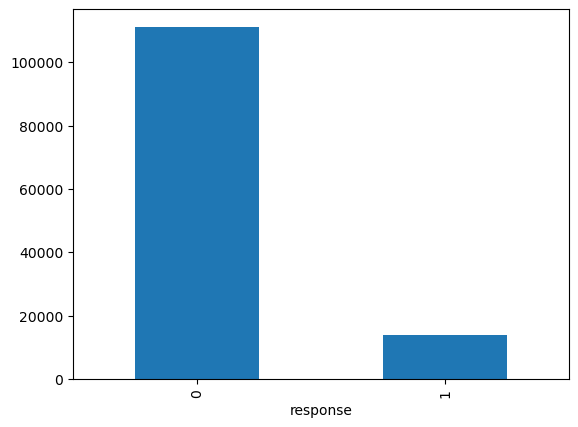

In [28]:
#Count the numbers of churn and active customers
churn_count=df['response'].value_counts()
#Plot
churn_count.plot(kind='bar')

<Axes: xlabel='month_year'>

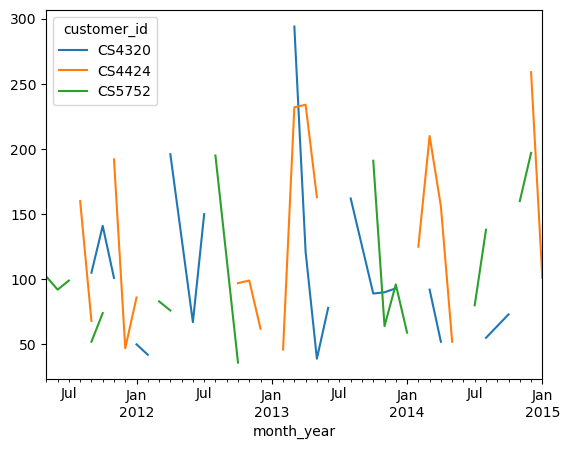

In [29]:
top_3_cus=monetary.sort_values(ascending=False).head(3).index

top_customer_df=df[df['customer_id'].isin(top_3_cus)]

top_customer_sales= top_customer_df.groupby(['customer_id','month_year'])['tran_amount'].sum().unstack(level=0)
top_customer_sales.plot(kind='line')
